## Data Preprocessing and Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [2]:
# Display a summary of the DataFrame including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [3]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [4]:
# Check for missing values
print('Missing values in each column:')
display(df.isnull().sum())

Missing values in each column:


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [5]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_rows}')

Number of duplicate rows: 0


New 'Date' column created and DataFrame sorted by date.


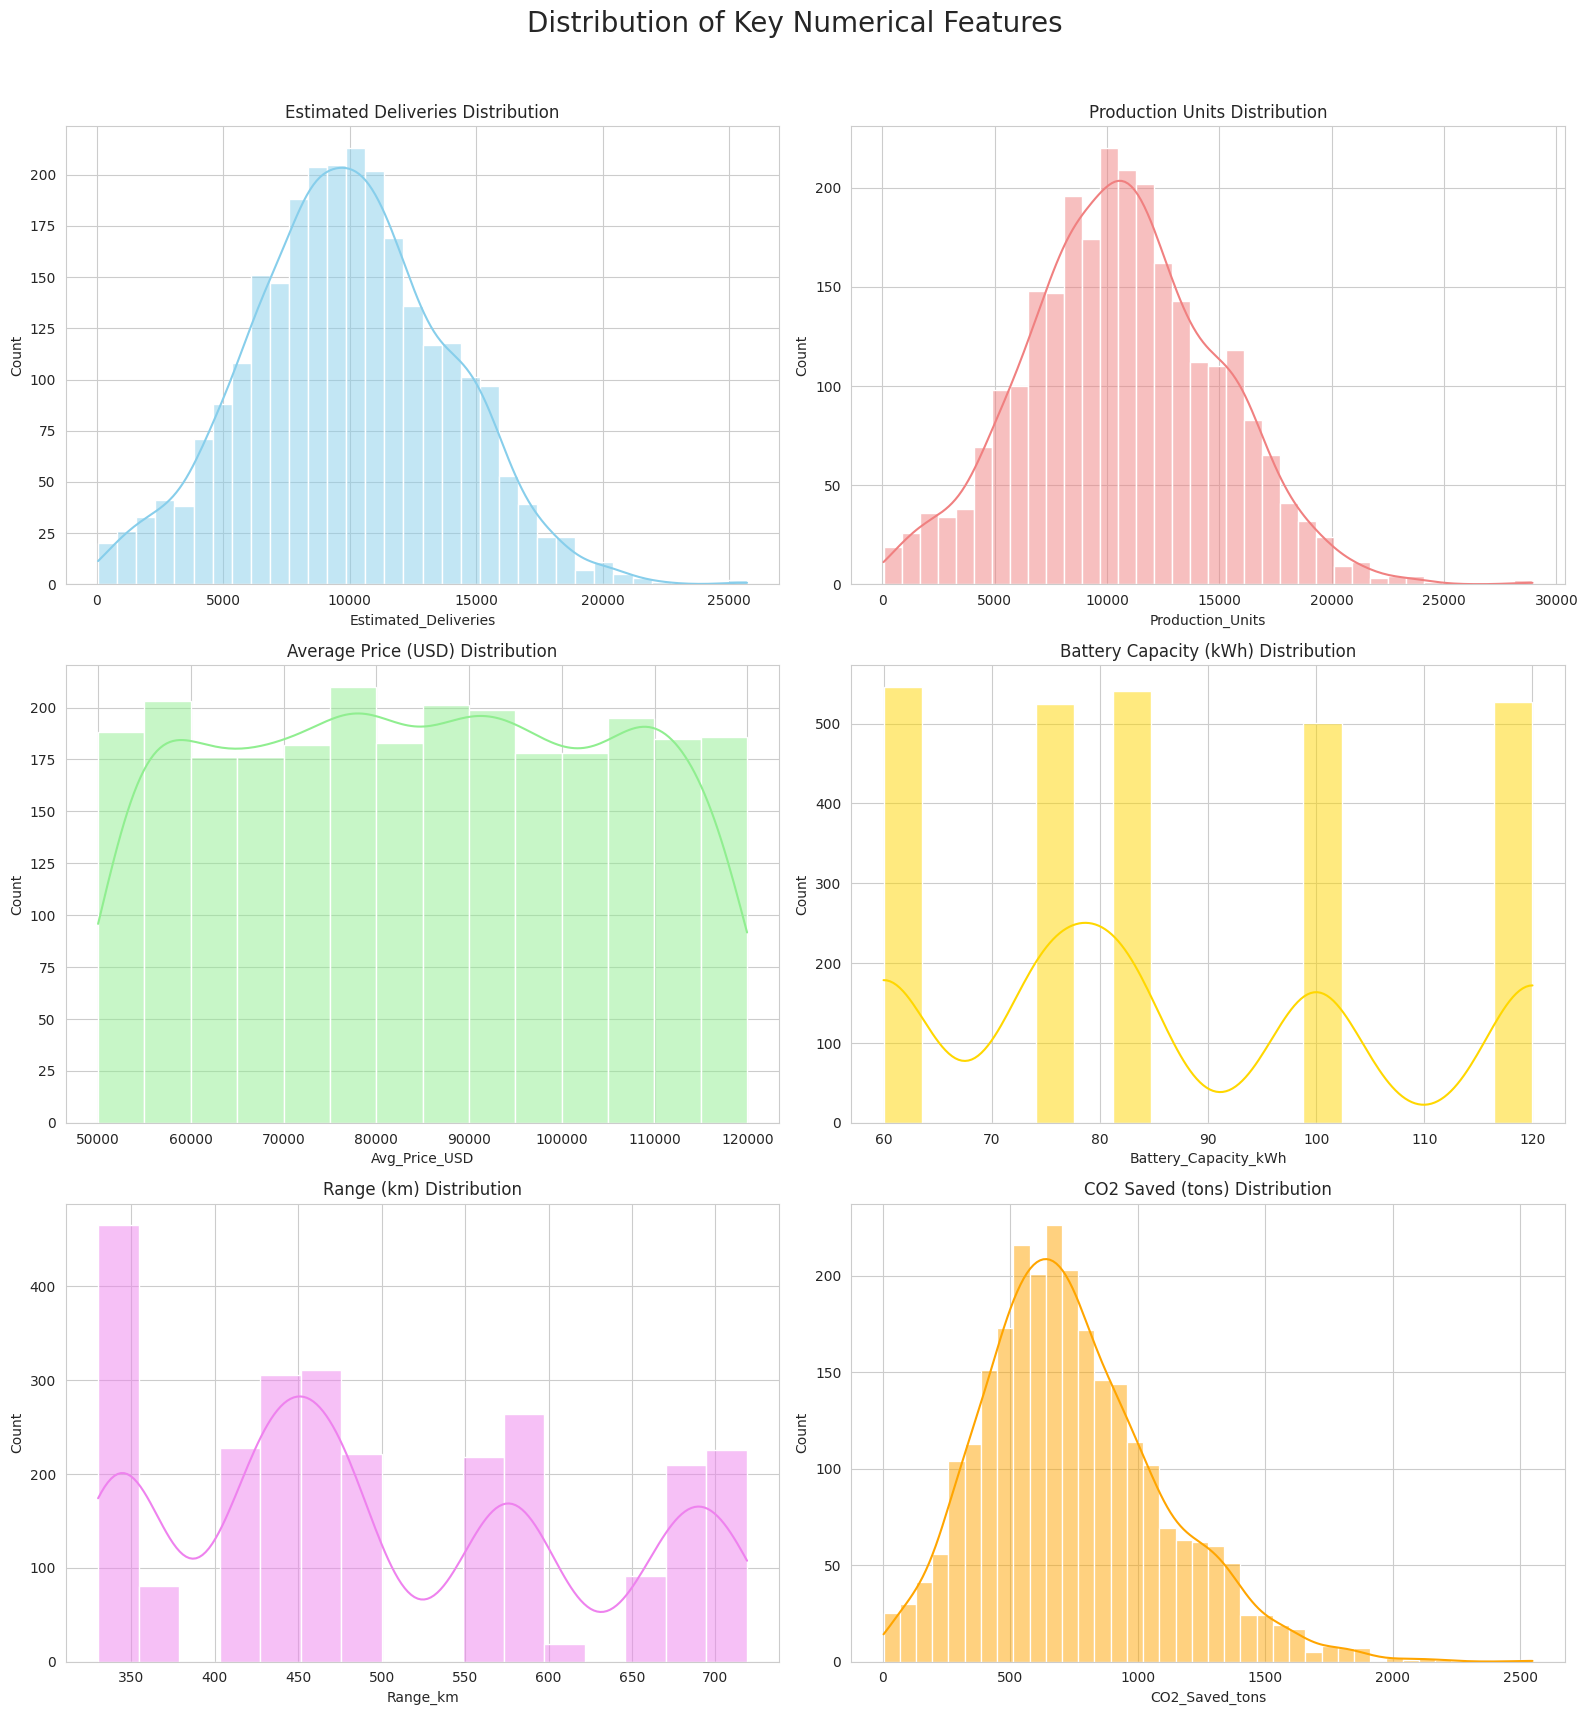

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 'Date' column for time-series analysis
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Sort by Date to ensure correct time-series plotting
df = df.sort_values(by='Date').reset_index(drop=True)

print("New 'Date' column created and DataFrame sorted by date.")

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Visualize distributions of key numerical features
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
fig.suptitle('Distribution of Key Numerical Features', fontsize=20)

sns.histplot(df['Estimated_Deliveries'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Estimated Deliveries Distribution')

sns.histplot(df['Production_Units'], kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Production Units Distribution')

sns.histplot(df['Avg_Price_USD'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Average Price (USD) Distribution')

sns.histplot(df['Battery_Capacity_kWh'], kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Battery Capacity (kWh) Distribution')

sns.histplot(df['Range_km'], kde=True, ax=axes[2, 0], color='violet')
axes[2, 0].set_title('Range (km) Distribution')

sns.histplot(df['CO2_Saved_tons'], kde=True, ax=axes[2, 1], color='orange')
axes[2, 1].set_title('CO2 Saved (tons) Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Categorical Feature Analysis

/tmp/ipykernel_2081/939035869.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Region'], ax=axes[0], palette='viridis', order = df['Region'].value_counts().index)
/tmp/ipykernel_2081/939035869.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Model'], ax=axes[1], palette='plasma', order = df['Model'].value_counts().index)
/tmp/ipykernel_2081/939035869.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Source_Type'], ax=axes[2], palette='cividis', order = df['Source_Type'].value_counts().index)


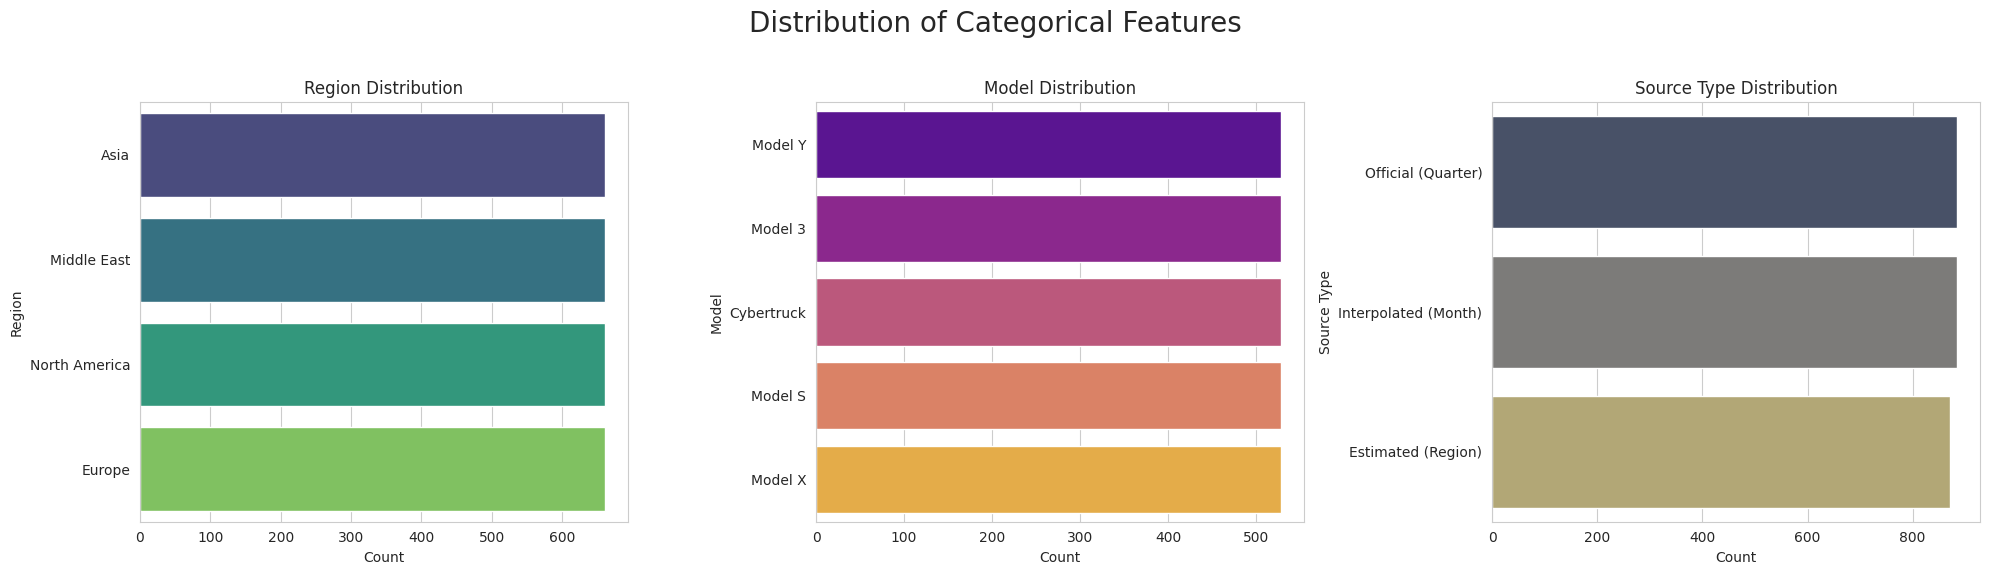

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze categorical features
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
fig.suptitle('Distribution of Categorical Features', fontsize=20)

sns.countplot(y=df['Region'], ax=axes[0], palette='viridis', order = df['Region'].value_counts().index)
axes[0].set_title('Region Distribution')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Region')

sns.countplot(y=df['Model'], ax=axes[1], palette='plasma', order = df['Model'].value_counts().index)
axes[1].set_title('Model Distribution')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Model')

sns.countplot(y=df['Source_Type'], ax=axes[2], palette='cividis', order = df['Source_Type'].value_counts().index)
axes[2].set_title('Source Type Distribution')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Source Type')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Correlation Analysis of Numerical Features

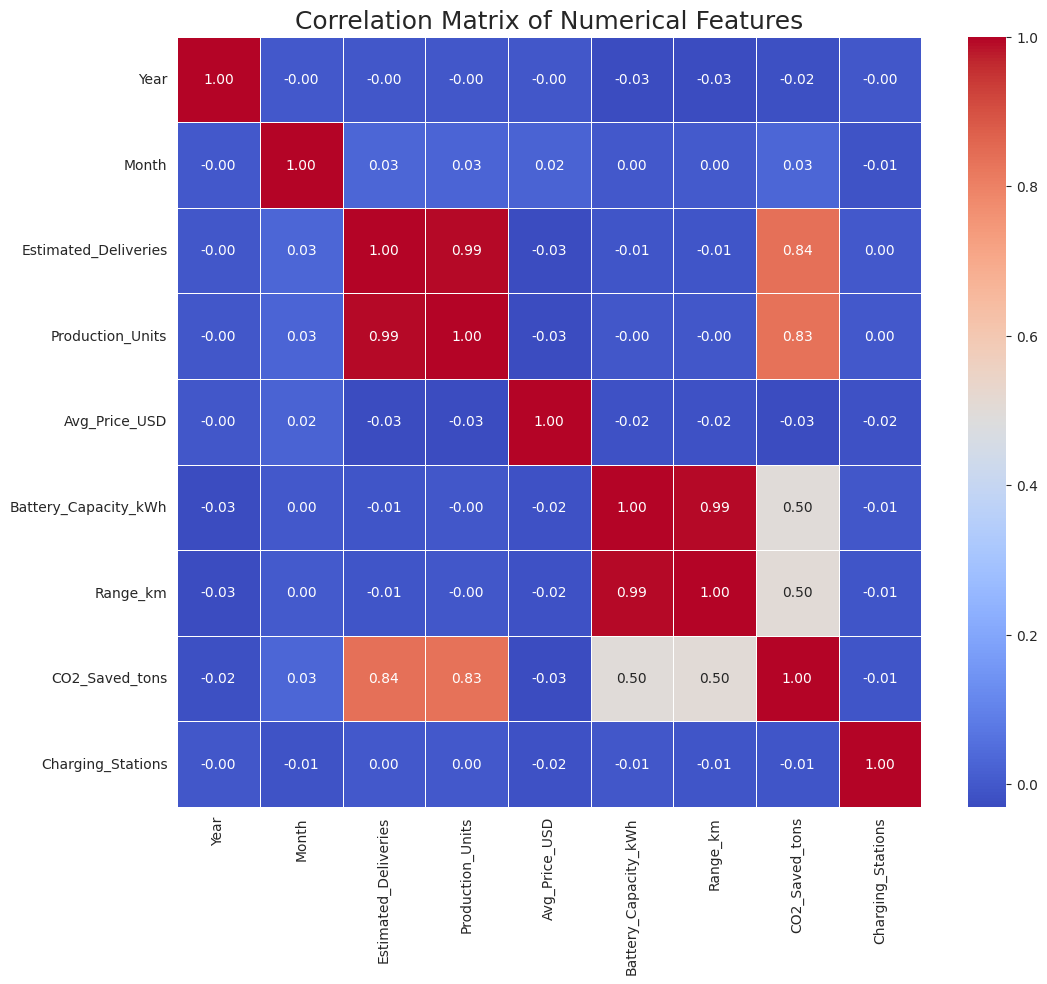

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=18)
plt.show()

### Time Series Analysis and Trend Visualization

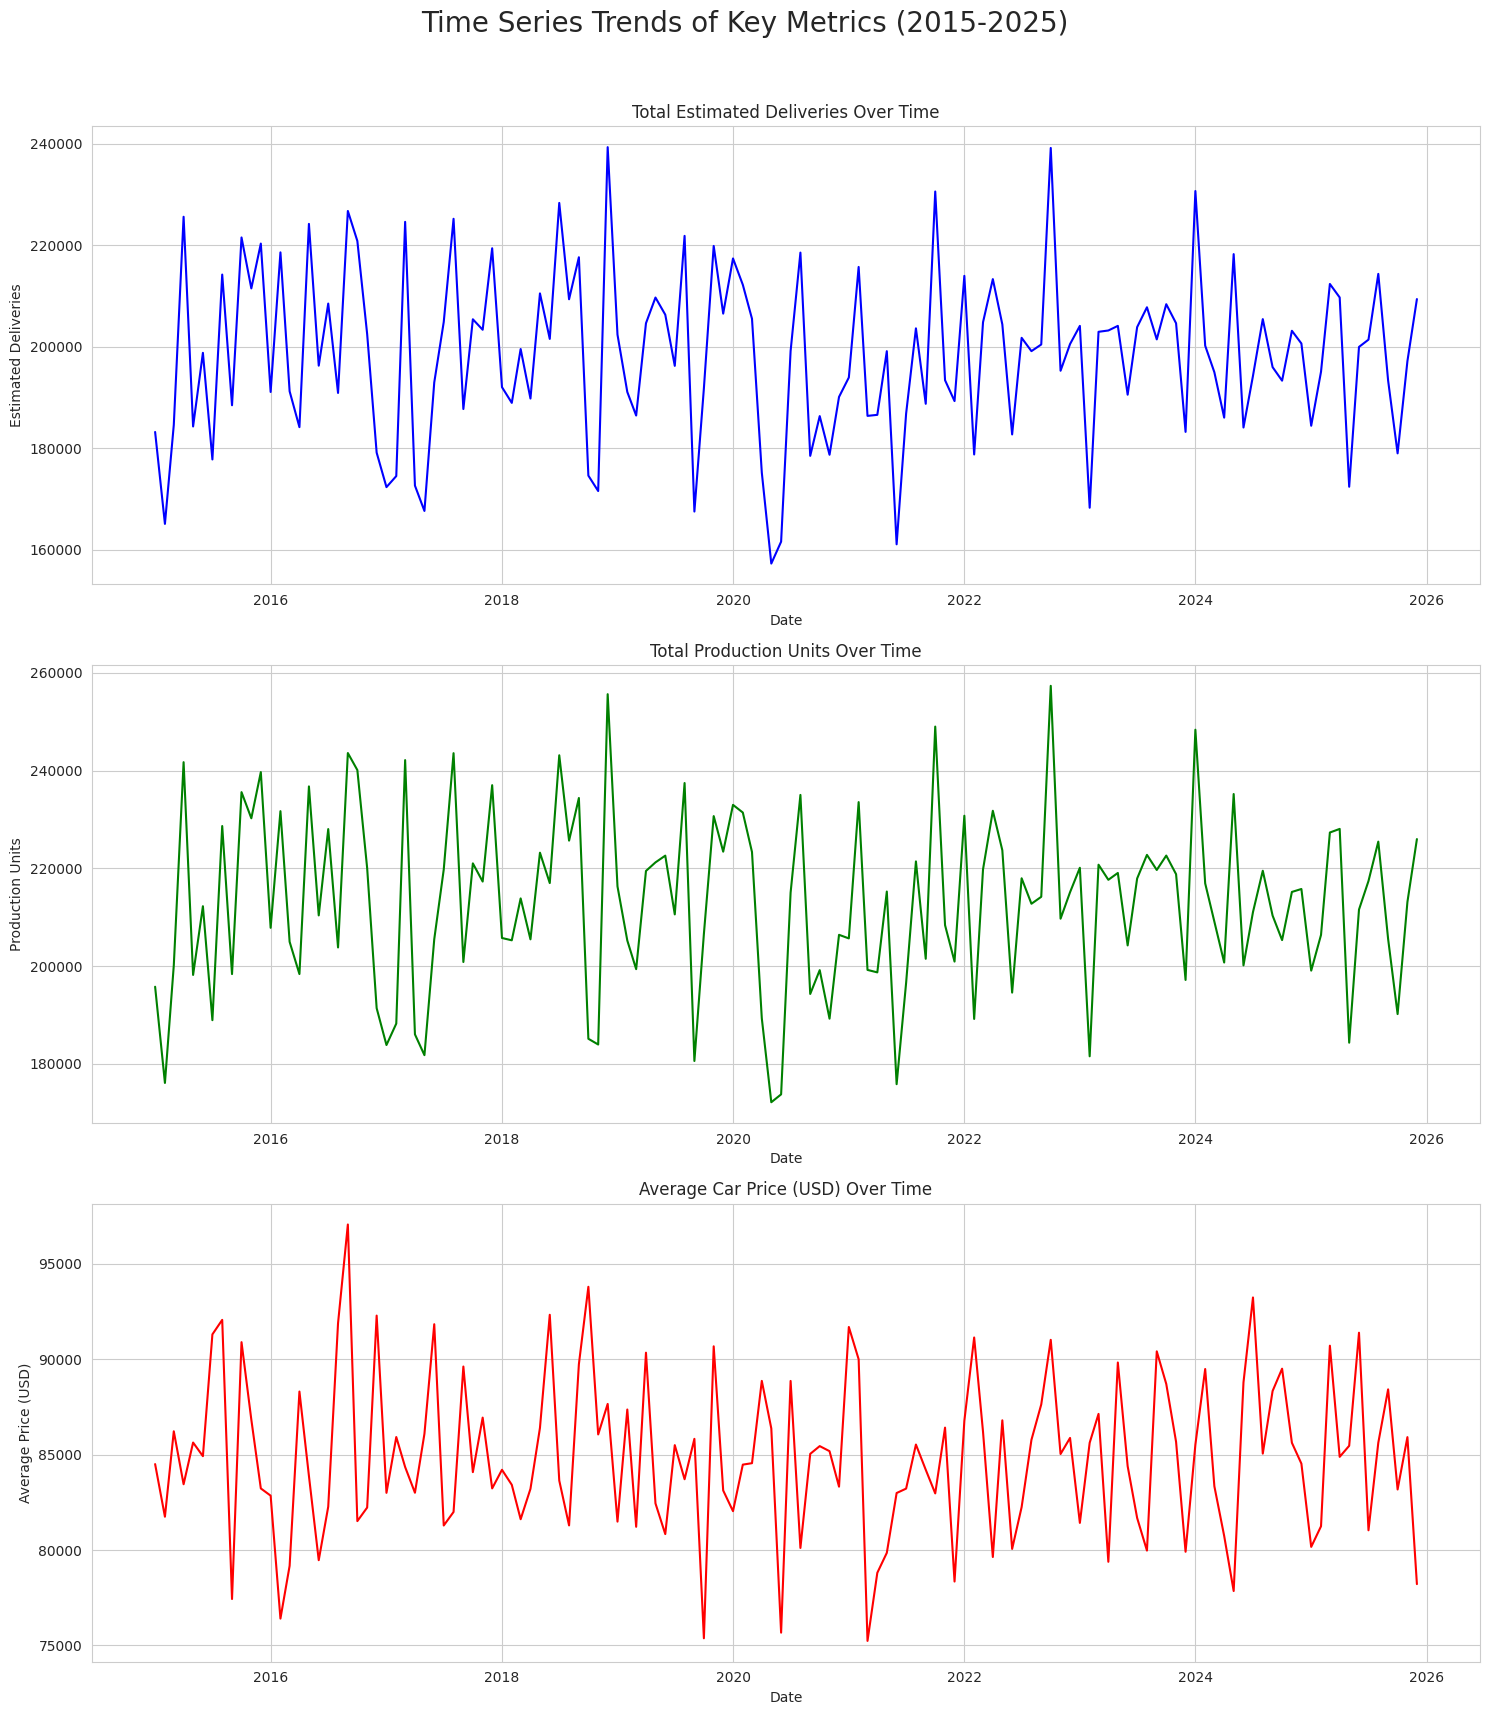

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Date and sum the relevant metrics for overall trends
time_series_df = df.groupby('Date').agg({
    'Estimated_Deliveries': 'sum',
    'Production_Units': 'sum',
    'Avg_Price_USD': 'mean' # Taking mean as Avg_Price_USD is already an average
}).reset_index()

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 18))
fig.suptitle('Time Series Trends of Key Metrics (2015-2025)', fontsize=20)

# Plot Estimated Deliveries over time
sns.lineplot(x='Date', y='Estimated_Deliveries', data=time_series_df, ax=axes[0], color='blue')
axes[0].set_title('Total Estimated Deliveries Over Time')
axes[0].set_ylabel('Estimated Deliveries')

# Plot Production Units over time
sns.lineplot(x='Date', y='Production_Units', data=time_series_df, ax=axes[1], color='green')
axes[1].set_title('Total Production Units Over Time')
axes[1].set_ylabel('Production Units')

# Plot Average Price USD over time
sns.lineplot(x='Date', y='Avg_Price_USD', data=time_series_df, ax=axes[2], color='red')
axes[2].set_title('Average Car Price (USD) Over Time')
axes[2].set_ylabel('Average Price (USD)')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## Feature Engineering

In [10]:
# Extract time-based features from the 'Date' column
df['Quarter'] = df['Date'].dt.quarter
df['Year_Month'] = df['Date'].dt.to_period('M')
df['Week_of_Year'] = df['Date'].dt.isocalendar().week.astype(int)
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Day_of_Year'] = df['Date'].dt.dayofyear
df['Is_Weekend'] = df['Day_of_Week'].isin([5, 6]).astype(int)

print("Time-based features (Quarter, Year_Month, Week_of_Year, Day_of_Week, Day_of_Year, Is_Weekend) created.")

# Display the DataFrame with new features
display(df.head())

Time-based features (Quarter, Year_Month, Week_of_Year, Day_of_Week, Day_of_Year, Is_Weekend) created.


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Year_Month,Week_of_Year,Day_of_Week,Day_of_Year,Is_Weekend
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,2015-01,1,3,1,0
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,2015-01,1,3,1,0
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,2015-01,1,3,1,0
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,2015-01,1,3,1,0
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,2015-01,1,3,1,0


### Creating Lag Features for Time Series Forecasting

In [11]:
# Sort data by Date, Region, and Model for correct lag calculation
df_sorted = df.sort_values(by=['Region', 'Model', 'Date']).reset_index(drop=True)

# Create lag features for 'Estimated_Deliveries' and 'Avg_Price_USD'
# Lag of 1 month for Deliveries and Avg Price
for col in ['Estimated_Deliveries', 'Avg_Price_USD']:
    df_sorted[f'{col}_lag1'] = df_sorted.groupby(['Region', 'Model'])[col].shift(1)

# Lag of 3 months for Deliveries and Avg Price
for col in ['Estimated_Deliveries', 'Avg_Price_USD']:
    df_sorted[f'{col}_lag3'] = df_sorted.groupby(['Region', 'Model'])[col].shift(3)

# Fill any NaN values created by shifting with 0 or an appropriate value
df_sorted.fillna(0, inplace=True) # or consider forward/backward fill based on context

print("Lag features created for Estimated_Deliveries and Avg_Price_USD.")
display(df_sorted.head())

Lag features created for Estimated_Deliveries and Avg_Price_USD.


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Quarter,Year_Month,Week_of_Year,Day_of_Week,Day_of_Year,Is_Weekend,Estimated_Deliveries_lag1,Avg_Price_USD_lag1,Estimated_Deliveries_lag3,Avg_Price_USD_lag3
0,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,...,1,2015-01,1,3,1,0,0.0,0.00,0.0,0.00
1,2015,2,Asia,Cybertruck,13254,14878,88864.06,75,432,858.86,...,1,2015-02,5,6,32,1,11325.0,54449.08,0.0,0.00
2,2015,3,Asia,Cybertruck,10257,11441,65107.47,100,581,893.90,...,1,2015-03,9,6,60,1,13254.0,88864.06,0.0,0.00
3,2015,4,Asia,Cybertruck,15221,15951,112686.63,60,341,778.55,...,2,2015-04,14,2,91,0,10257.0,65107.47,11325.0,54449.08
4,2015,5,Asia,Cybertruck,6406,7281,107577.61,75,448,430.48,...,2,2015-05,18,4,121,0,15221.0,112686.63,13254.0,88864.06


### Encoding Categorical Features

In [12]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns for encoding
categorical_cols = ['Region', 'Model', 'Source_Type']

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the categorical columns
encoded_features = encoder.fit_transform(df_sorted[categorical_cols])

# Create a DataFrame from the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenate the encoded features with the original DataFrame
df_encoded = pd.concat([df_sorted.drop(columns=categorical_cols), encoded_df], axis=1)

print("Categorical features encoded using OneHotEncoder.")
display(df_encoded.head())

Categorical features encoded using OneHotEncoder.


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,...,Region_Middle East,Region_North America,Model_Cybertruck,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Estimated (Region),Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2015,1,11325,11887,54449.08,60,339,575.88,6902,2015-01-01,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2015,2,13254,14878,88864.06,75,432,858.86,5902,2015-02-01,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2015,3,10257,11441,65107.47,100,581,893.90,4024,2015-03-01,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2015,4,15221,15951,112686.63,60,341,778.55,3130,2015-04-01,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2015,5,6406,7281,107577.61,75,448,430.48,11708,2015-05-01,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Regression Modeling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define target variables for sales/deliveries and price
TARGET_DELIVERIES = 'Estimated_Deliveries'
TARGET_PRICE = 'Avg_Price_USD'

# Drop non-numeric and target-related columns that should not be features
# We'll use df_encoded as it contains all processed features
features_df = df_encoded.drop(columns=[
    'Year', 'Month', 'Date', 'Year_Month', # These are used to create other features or are directly related to the date
    TARGET_DELIVERIES, TARGET_PRICE, # Target variables
    'Estimated_Deliveries_lag1', 'Estimated_Deliveries_lag3', # These are features, but we don't want to predict them directly now
    'Avg_Price_USD_lag1', 'Avg_Price_USD_lag3' # These are features, but we don't want to predict them directly now
], errors='ignore')

# Also drop 'CO2_Saved_tons' and 'Production_Units' as they are highly correlated with deliveries and might be a proxy target
features_df = features_df.drop(columns=['CO2_Saved_tons', 'Production_Units', 'Charging_Stations'], errors='ignore')

# Align columns for consistency after dropping
features = features_df.columns

# Define X (features) and y_deliveries (target for deliveries) and y_price (target for price)
X = df_encoded[features]
y_deliveries = df_encoded[TARGET_DELIVERIES]
y_price = df_encoded[TARGET_PRICE]

# Split data into training and testing sets for deliveries
X_train_del, X_test_del, y_train_del, y_test_del = train_test_split(
    X, y_deliveries, test_size=0.2, random_state=42
)

# Split data into training and testing sets for price
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X, y_price, test_size=0.2, random_state=42
)

print(f"Features used for modeling: {list(features)}")
print(f"Shape of X_train_del: {X_train_del.shape}")
print(f"Shape of y_train_del: {y_train_del.shape}")
print(f"Shape of X_test_del: {X_test_del.shape}")
print(f"Shape of y_test_del: {y_test_del.shape}")

print("\nData split into training and testing sets for both deliveries and price.")

Features used for modeling: ['Battery_Capacity_kWh', 'Range_km', 'Quarter', 'Week_of_Year', 'Day_of_Week', 'Day_of_Year', 'Is_Weekend', 'Region_Asia', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Cybertruck', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Estimated (Region)', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)']
Shape of X_train_del: (2112, 19)
Shape of y_train_del: (2112,)
Shape of X_test_del: (528, 19)
Shape of y_test_del: (528,)

Data split into training and testing sets for both deliveries and price.


### Model Training and Evaluation (Deliveries)

In [14]:
# Initialize and train a Linear Regression model for Estimated_Deliveries
model_deliveries = LinearRegression()
model_deliveries.fit(X_train_del, y_train_del)

# Make predictions on the test set
y_pred_del = model_deliveries.predict(X_test_del)

# Evaluate the model
mse_del = mean_squared_error(y_test_del, y_pred_del)
rmse_del = np.sqrt(mse_del)
r2_del = r2_score(y_test_del, y_pred_del)

print(f"Linear Regression Model for Estimated Deliveries:")
print(f"Mean Squared Error (MSE): {mse_del:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_del:.2f}")
print(f"R-squared (R2): {r2_del:.2f}")

Linear Regression Model for Estimated Deliveries:
Mean Squared Error (MSE): 15447066.56
Root Mean Squared Error (RMSE): 3930.28
R-squared (R2): -0.01


### Model Training and Evaluation (Average Price)

In [15]:
# Initialize and train a Linear Regression model for Avg_Price_USD
model_price = LinearRegression()
model_price.fit(X_train_price, y_train_price)

# Make predictions on the test set
y_pred_price = model_price.predict(X_test_price)

# Evaluate the model
mse_price = mean_squared_error(y_test_price, y_pred_price)
rmse_price = np.sqrt(mse_price)
r2_price = r2_score(y_test_price, y_pred_price)

print(f"\nLinear Regression Model for Average Price (USD):")
print(f"Mean Squared Error (MSE): {mse_price:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_price:.2f}")
print(f"R-squared (R2): {r2_price:.2f}")


Linear Regression Model for Average Price (USD):
Mean Squared Error (MSE): 446411858.05
Root Mean Squared Error (RMSE): 21128.46
R-squared (R2): -0.01


## Hyperparameter Tuning (using RandomForestRegressor)

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define a smaller parameter grid for quicker execution (can be expanded)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_leaf': [1, 2]
}

# Initialize RandomForestRegressor for deliveries
rf_deliveries = RandomForestRegressor(random_state=42)

# Setup GridSearchCV for deliveries
grid_search_deliveries = GridSearchCV(estimator=rf_deliveries, param_grid=param_grid,
                                      cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

print("Starting Hyperparameter Tuning for Estimated Deliveries...")
grid_search_deliveries.fit(X_train_del, y_train_del)

print("Best parameters for Deliveries:", grid_search_deliveries.best_params_)
print("Best RMSE for Deliveries (from grid search):", np.sqrt(-grid_search_deliveries.best_score_))

# Evaluate best model for deliveries on the test set
best_rf_deliveries = grid_search_deliveries.best_estimator_
y_pred_tuned_del = best_rf_deliveries.predict(X_test_del)
mse_tuned_del = mean_squared_error(y_test_del, y_pred_tuned_del)
rmse_tuned_del = np.sqrt(mse_tuned_del)
r2_tuned_del = r2_score(y_test_del, y_pred_tuned_del)

print(f"\nTunned RandomForest Regressor for Estimated Deliveries on Test Set:")
print(f"Mean Squared Error (MSE): {mse_tuned_del:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned_del:.2f}")
print(f"R-squared (R2): {r2_tuned_del:.2f}")

Starting Hyperparameter Tuning for Estimated Deliveries...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Deliveries: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 100}
Best RMSE for Deliveries (from grid search): 3980.1072469879646

Tunned RandomForest Regressor for Estimated Deliveries on Test Set:
Mean Squared Error (MSE): 15332154.01
Root Mean Squared Error (RMSE): 3915.63
R-squared (R2): 0.00


In [17]:
# Initialize RandomForestRegressor for price
rf_price = RandomForestRegressor(random_state=42)

# Setup GridSearchCV for price
grid_search_price = GridSearchCV(estimator=rf_price, param_grid=param_grid,
                                 cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

print("\nStarting Hyperparameter Tuning for Average Price...")
grid_search_price.fit(X_train_price, y_train_price)

print("Best parameters for Price:", grid_search_price.best_params_)
print("Best RMSE for Price (from grid search):", np.sqrt(-grid_search_price.best_score_))

# Evaluate best model for price on the test set
best_rf_price = grid_search_price.best_estimator_
y_pred_tuned_price = best_rf_price.predict(X_test_price)
mse_tuned_price = mean_squared_error(y_test_price, y_pred_tuned_price)
rmse_tuned_price = np.sqrt(mse_tuned_price)
r2_tuned_price = r2_score(y_test_price, y_pred_tuned_price)

print(f"\nTunned RandomForest Regressor for Average Price (USD) on Test Set:")
print(f"Mean Squared Error (MSE): {mse_tuned_price:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned_price:.2f}")
print(f"R-squared (R2): {r2_tuned_price:.2f}")


Starting Hyperparameter Tuning for Average Price...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Price: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
Best RMSE for Price (from grid search): 19994.44749229449

Tunned RandomForest Regressor for Average Price (USD) on Test Set:
Mean Squared Error (MSE): 444849857.65
Root Mean Squared Error (RMSE): 21091.46
R-squared (R2): -0.01


## Time Series Forecasting

Training data for Prophet: 120 months
Validation data for Prophet: 12 months


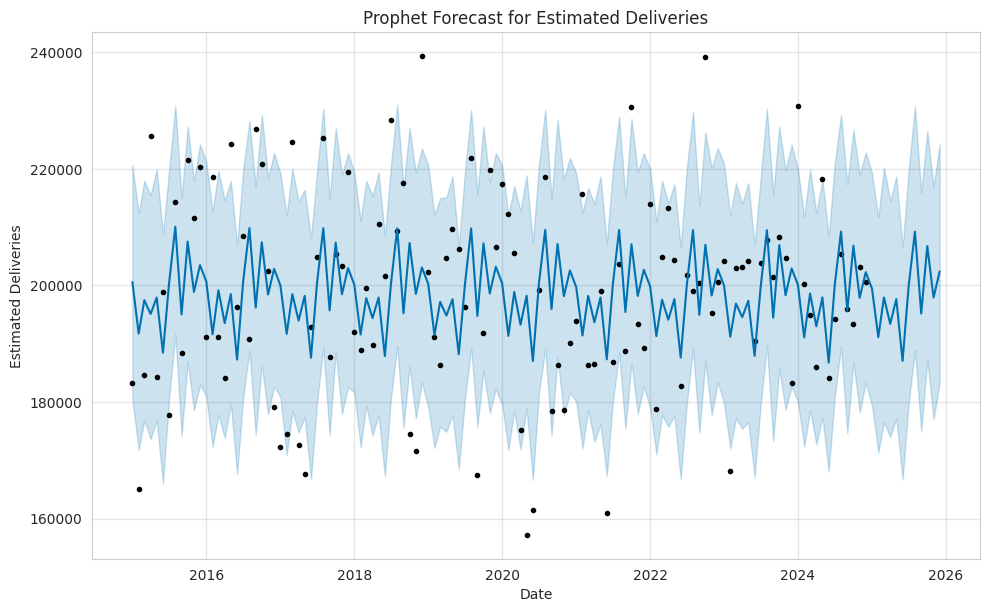

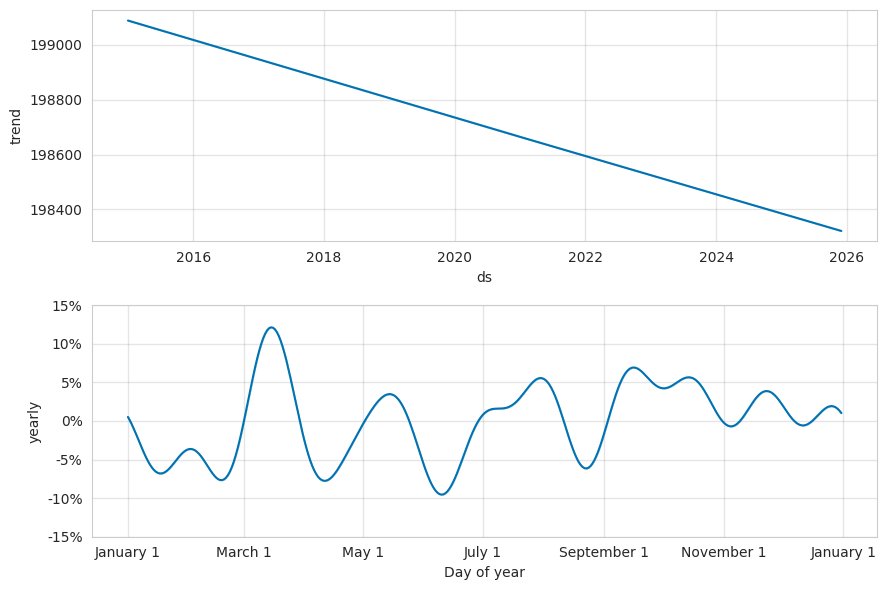


Prophet Model Evaluation for Estimated Deliveries:
Mean Absolute Error (MAE): 10989.93
Root Mean Squared Error (RMSE): 14064.92


In [19]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prepare data for Prophet: Prophet requires columns 'ds' (datetime) and 'y' (target)
# We will focus on forecasting overall Estimated Deliveries.

# Aggregate data by Date for overall deliveries
time_series_data = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
time_series_data.rename(columns={'Date': 'ds', 'Estimated_Deliveries': 'y'}, inplace=True)

# Split data into training and validation sets for time series
# Use the last 12 months for validation
train_size = len(time_series_data) - 12
train_prophet = time_series_data.iloc[:train_size]
val_prophet = time_series_data.iloc[train_size:]

print(f"Training data for Prophet: {len(train_prophet)} months")
print(f"Validation data for Prophet: {len(val_prophet)} months")

# Initialize and train the Prophet model
model_prophet = Prophet(
    seasonality_mode='multiplicative',
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=True
)
model_prophet.fit(train_prophet)

# Create a future dataframe for predictions
future = model_prophet.make_future_dataframe(periods=len(val_prophet), freq='MS')

# Make predictions
forecast = model_prophet.predict(future)

# Extract predictions for the validation period
forecast_val = forecast.iloc[train_size:]

# Plot the forecast
fig_prophet = model_prophet.plot(forecast)
plt.title('Prophet Forecast for Estimated Deliveries')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.show()

# Plot components of the forecast
fig_components = model_prophet.plot_components(forecast)
plt.show()

# Evaluate the forecast
mae_prophet = mean_absolute_error(val_prophet['y'], forecast_val['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(val_prophet['y'], forecast_val['yhat']))

print(f"\nProphet Model Evaluation for Estimated Deliveries:")
print(f"Mean Absolute Error (MAE): {mae_prophet:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_prophet:.2f}")

## Time Series Forecasting

Training data for Prophet: 120 months
Validation data for Prophet: 12 months


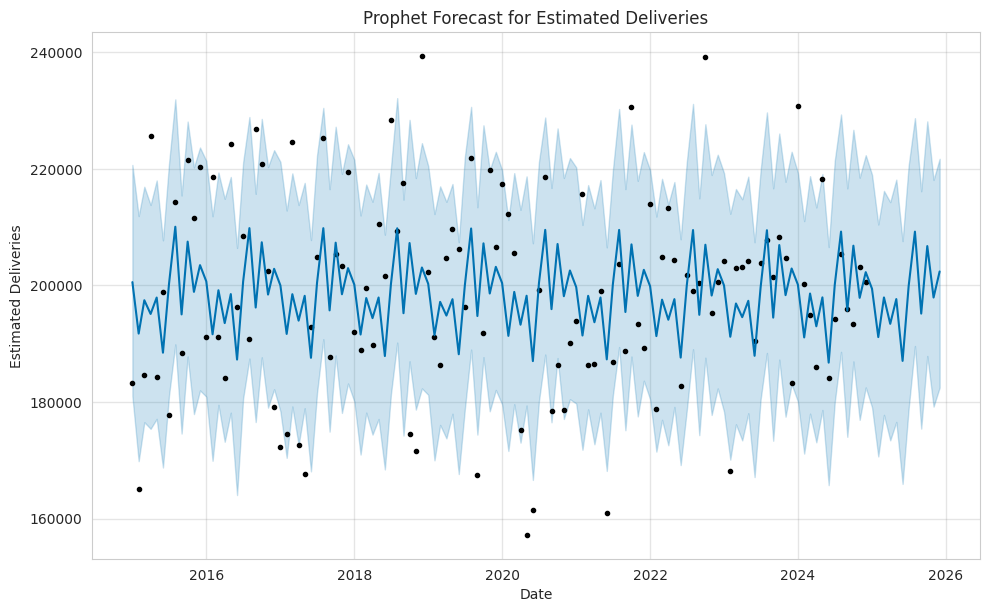

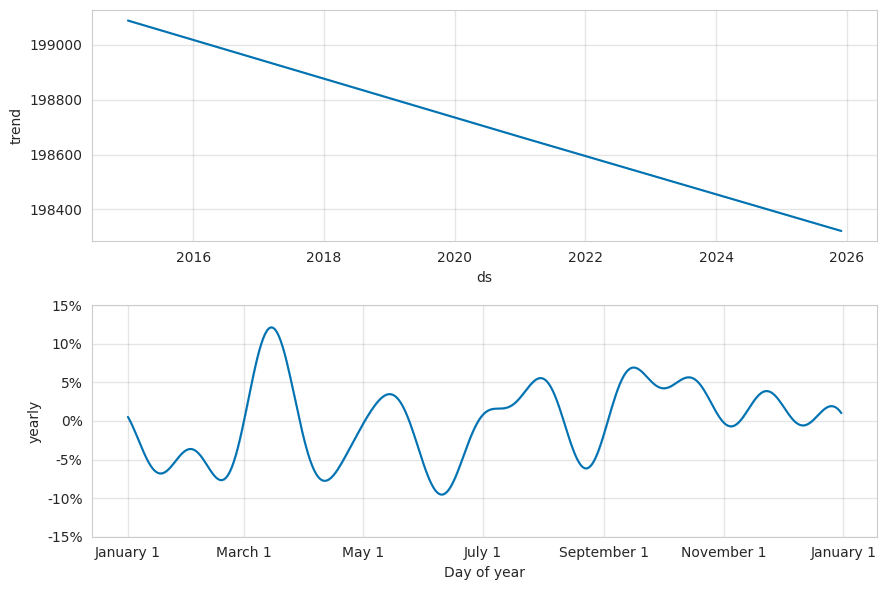


Prophet Model Evaluation for Estimated Deliveries:
Mean Absolute Error (MAE): 10989.93
Root Mean Squared Error (RMSE): 14064.92


In [18]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare data for Prophet: Prophet requires columns 'ds' (datetime) and 'y' (target)
# We will focus on forecasting overall Estimated Deliveries.

# Aggregate data by Date for overall deliveries
time_series_data = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
time_series_data.rename(columns={'Date': 'ds', 'Estimated_Deliveries': 'y'}, inplace=True)

# Split data into training and validation sets for time series
# Use the last 12 months for validation
train_size = len(time_series_data) - 12
train_prophet = time_series_data.iloc[:train_size]
val_prophet = time_series_data.iloc[train_size:]

print(f"Training data for Prophet: {len(train_prophet)} months")
print(f"Validation data for Prophet: {len(val_prophet)} months")

# Initialize and train the Prophet model
model_prophet = Prophet(
    seasonality_mode='multiplicative',
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=True
)
model_prophet.fit(train_prophet)

# Create a future dataframe for predictions
future = model_prophet.make_future_dataframe(periods=len(val_prophet), freq='MS')

# Make predictions
forecast = model_prophet.predict(future)

# Extract predictions for the validation period
forecast_val = forecast.iloc[train_size:]

# Plot the forecast
fig_prophet = model_prophet.plot(forecast)
plt.title('Prophet Forecast for Estimated Deliveries')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.show()

# Plot components of the forecast
fig_components = model_prophet.plot_components(forecast)
plt.show()

# Evaluate the forecast
mae_prophet = mean_absolute_error(val_prophet['y'], forecast_val['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(val_prophet['y'], forecast_val['yhat']))

print(f"\nProphet Model Evaluation for Estimated Deliveries:")
print(f"Mean Absolute Error (MAE): {mae_prophet:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_prophet:.2f}")